# LightGBM (Light Gradient Boosting Machine)

## Overview
LightGBM is a fast, distributed, high-performance gradient boosting framework developed by **Microsoft**. It is designed to be faster and use less memory than XGBoost, especially on large datasets.

### Key Innovations over XGBoost:
| Feature | XGBoost | LightGBM |
|---------|---------|----------|
| Tree growth | Level-wise (breadth-first) | **Leaf-wise** (best-first) |
| Speed | Fast | **Faster** (histogram-based splits) |
| Memory | High | **Lower** (bins continuous features) |
| Categorical | Manual encoding | **Native** support |
| Large data | Good | **Excellent** (GOSS + EFB) |

### Two Core Innovations:
**GOSS (Gradient-based One-Side Sampling):**
Keep all samples with large gradients (hard examples) and randomly drop samples with small gradients.

**EFB (Exclusive Feature Bundling):**
Bundle mutually exclusive sparse features into one, reducing the number of features.

### Leaf-wise vs Level-wise Growth:
$$\text{Level-wise: split ALL leaves at each depth level}$$
$$\text{Leaf-wise: split ONLY the leaf with maximum loss reduction}$$

### Key Hyperparameters:
| Parameter | Role |
|-----------|------|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Step size shrinkage |
| `num_leaves` | Max leaves per tree (key for LightGBM) |
| `max_depth` | Max depth (-1 = unlimited) |
| `subsample` | Row subsampling fraction |
| `colsample_bytree` | Feature fraction per tree |
| `reg_alpha` | L1 regularization |
| `reg_lambda` | L2 regularization |
| `min_child_samples` | Min samples per leaf |

---
### Topics Covered
1. Install & import LightGBM
2. Leaf-wise vs Level-wise growth intuition
3. Classification — fit and evaluate
4. Decision boundary
5. Early stopping with validation curve
6. Effect of num_leaves
7. Feature importance (split vs gain)
8. Categorical feature handling
9. LightGBM Regressor
10. Hyperparameter tuning with GridSearchCV
11. Real-world offline-safe dataset
12. XGBoost vs LightGBM speed & accuracy comparison


## 1. Install & Import Libraries

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    from lightgbm import LGBMClassifier, LGBMRegressor
    print(f'LightGBM version : {lgb.__version__}')
except ImportError:
    print('LightGBM not found. Installing...')
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb
    from lightgbm import LGBMClassifier, LGBMRegressor
    print(f'LightGBM installed. Version: {lgb.__version__}')

try:
    from xgboost import XGBClassifier, XGBRegressor
    import xgboost as xgb
    print(f'XGBoost version  : {xgb.__version__}')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    from xgboost import XGBClassifier, XGBRegressor

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.datasets import make_classification, make_regression
import time

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
    'lgbm':      '#27AE60',
    'xgb':       '#E74C3C',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('All libraries ready!')

LightGBM version : 4.6.0
XGBoost version  : 3.3.0
All libraries ready!


## 2. Leaf-wise vs Level-wise Growth — Intuition

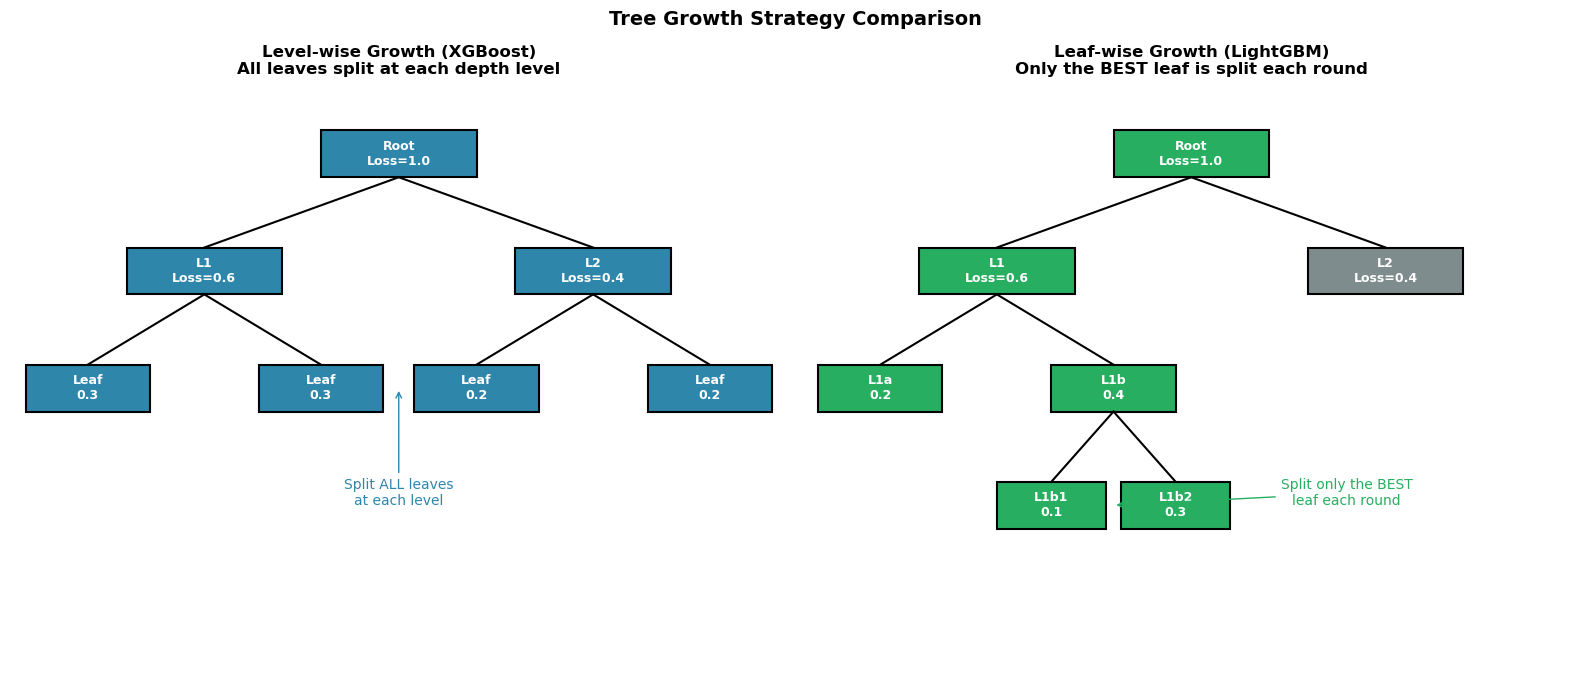

Level-wise : symmetric, stable, less prone to overfit, slower convergence
Leaf-wise  : asymmetric, faster convergence, lower loss, can overfit on small data
             -> Control with num_leaves and min_child_samples


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def draw_node(ax, x, y, w, h, label, color, fontsize=9):
    rect = plt.Rectangle((x-w/2, y-h/2), w, h,
                          facecolor=color, edgecolor='black', linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color='white')

def draw_edge(ax, x1, y1, x2, y2):
    ax.plot([x1, x2], [y1, y2], 'k-', linewidth=1.5)

# --- Level-wise (XGBoost style) ---
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Level-wise Growth (XGBoost)\nAll leaves split at each depth level',
             fontsize=12, fontweight='bold', pad=15)

# Depth 0
draw_node(ax, 5, 9, 2, 0.8, 'Root\nLoss=1.0', COLORS['primary'])
# Depth 1
draw_node(ax, 2.5, 7, 2, 0.8, 'L1\nLoss=0.6', COLORS['primary'])
draw_node(ax, 7.5, 7, 2, 0.8, 'L2\nLoss=0.4', COLORS['primary'])
draw_edge(ax, 5, 8.6, 2.5, 7.4)
draw_edge(ax, 5, 8.6, 7.5, 7.4)
# Depth 2 — ALL 4 leaves split
for x, loss, color in zip([1, 4, 6, 9], ['0.3','0.3','0.2','0.2'],
                            [COLORS['primary']]*4):
    parent_x = 2.5 if x < 5 else 7.5
    draw_node(ax, x, 5, 1.6, 0.8, f'Leaf\n{loss}', color)
    draw_edge(ax, parent_x, 6.6, x, 5.4)

ax.annotate('Split ALL leaves\nat each level', xy=(5, 5), xytext=(5, 3),
            fontsize=10, ha='center', color=COLORS['primary'],
            arrowprops=dict(arrowstyle='->', color=COLORS['primary']))

# --- Leaf-wise (LightGBM style) ---
ax = axes[1]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Leaf-wise Growth (LightGBM)\nOnly the BEST leaf is split each round',
             fontsize=12, fontweight='bold', pad=15)

draw_node(ax, 5, 9, 2, 0.8, 'Root\nLoss=1.0', COLORS['lgbm'])
draw_node(ax, 2.5, 7, 2, 0.8, 'L1\nLoss=0.6', COLORS['lgbm'])   # best -> split
draw_node(ax, 7.5, 7, 2, 0.8, 'L2\nLoss=0.4', COLORS['neutral']) # not split yet
draw_edge(ax, 5, 8.6, 2.5, 7.4)
draw_edge(ax, 5, 8.6, 7.5, 7.4)
# Only L1 (best leaf) is split
draw_node(ax, 1, 5, 1.6, 0.8, 'L1a\n0.2', COLORS['lgbm'])
draw_node(ax, 4, 5, 1.6, 0.8, 'L1b\n0.4', COLORS['lgbm'])
draw_edge(ax, 2.5, 6.6, 1, 5.4)
draw_edge(ax, 2.5, 6.6, 4, 5.4)
# L1b is now the best -> split again
draw_node(ax, 3.2, 3, 1.4, 0.8, 'L1b1\n0.1', COLORS['lgbm'])
draw_node(ax, 4.8, 3, 1.4, 0.8, 'L1b2\n0.3', COLORS['lgbm'])
draw_edge(ax, 4, 4.6, 3.2, 3.4)
draw_edge(ax, 4, 4.6, 4.8, 3.4)

ax.annotate('Split only the BEST\nleaf each round', xy=(4, 3), xytext=(7, 3),
            fontsize=10, ha='center', color=COLORS['lgbm'],
            arrowprops=dict(arrowstyle='->', color=COLORS['lgbm']))

plt.suptitle('Tree Growth Strategy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Level-wise : symmetric, stable, less prone to overfit, slower convergence')
print('Leaf-wise  : asymmetric, faster convergence, lower loss, can overfit on small data')
print('             -> Control with num_leaves and min_child_samples')

## 3. Generate Dataset & Fit LightGBM

In [15]:
np.random.seed(42)
X, y = make_classification(
    n_samples=700, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, class_sep=1.0, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lgbm_clf = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_clf.fit(X_train, y_train)

y_pred = lgbm_clf.predict(X_test)
y_prob = lgbm_clf.predict_proba(X_test)[:, 1]

print('=== LightGBM Classifier ===')
print(f'n_estimators     : {lgbm_clf.n_estimators}')
print(f'learning_rate    : {lgbm_clf.learning_rate}')
print(f'num_leaves       : {lgbm_clf.num_leaves}')
print(f'subsample        : {lgbm_clf.subsample}')
print(f'colsample_bytree : {lgbm_clf.colsample_bytree}')
print(f'Test Accuracy    : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC     : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Test F1 Score    : {f1_score(y_test, y_pred):.4f}')

=== LightGBM Classifier ===
n_estimators     : 100
learning_rate    : 0.1
num_leaves       : 31
subsample        : 0.8
colsample_bytree : 0.8
Test Accuracy    : 0.9000
Test ROC-AUC     : 0.9711
Test F1 Score    : 0.9000


## 4. Decision Boundary Visualization

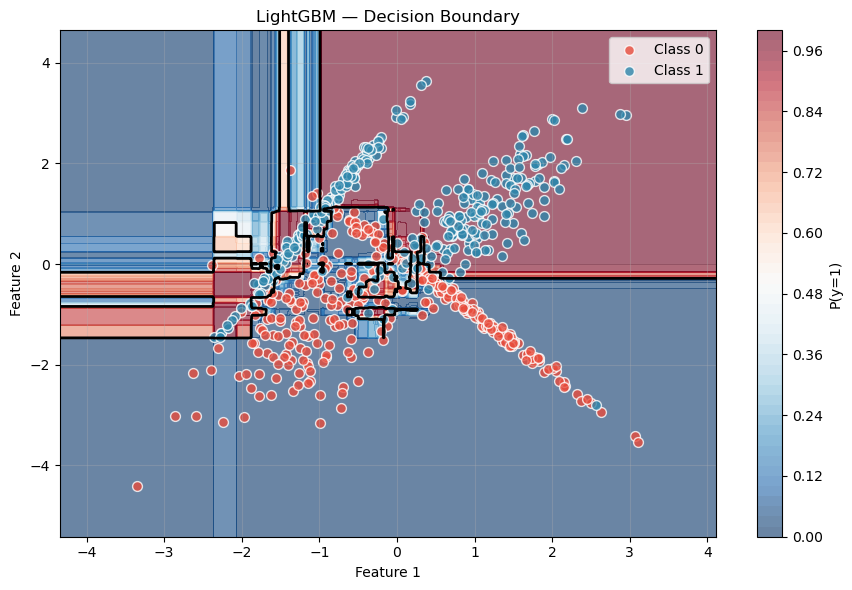

In [16]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = lgbm_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'],
            edgecolors='white', s=50, alpha=0.8, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'],
            edgecolors='white', s=50, alpha=0.8, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('LightGBM — Decision Boundary')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Early Stopping with Validation Curve

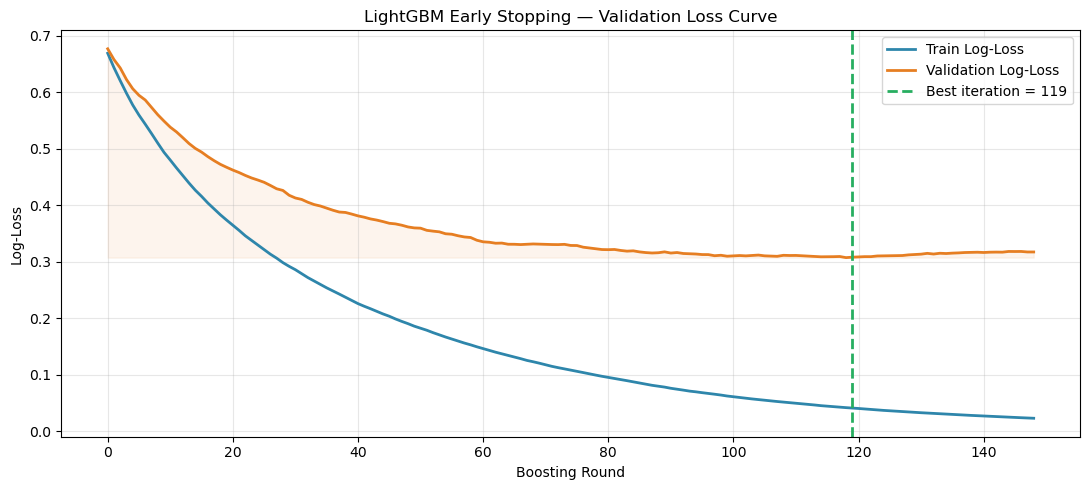

Best iteration  : 119
Test Accuracy   : 0.8812
Test ROC-AUC    : 0.9714


In [17]:
np.random.seed(10)
X_es, y_es = make_classification(
    n_samples=800, n_features=20, n_informative=12,
    n_redundant=5, random_state=10
)
X_es_tr, X_es_te, y_es_tr, y_es_te = train_test_split(
    X_es, y_es, test_size=0.2, random_state=42, stratify=y_es
)
X_es_tr2, X_es_val, y_es_tr2, y_es_val = train_test_split(
    X_es_tr, y_es_tr, test_size=0.2, random_state=42, stratify=y_es_tr
)

callbacks = [
    lgb.early_stopping(stopping_rounds=30, verbose=False),
    lgb.log_evaluation(period=-1)
]

lgbm_es = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_es.fit(
    X_es_tr2, y_es_tr2,
    eval_set=[(X_es_tr2, y_es_tr2), (X_es_val, y_es_val)],
    callbacks=callbacks
)

best_iter = lgbm_es.best_iteration_
evals     = lgbm_es.evals_result_
train_log = evals['training']['binary_logloss']
val_log   = evals['valid_1']['binary_logloss']

plt.figure(figsize=(11, 5))
plt.plot(train_log, color=COLORS['primary'],   linewidth=2, label='Train Log-Loss')
plt.plot(val_log,   color=COLORS['secondary'], linewidth=2, label='Validation Log-Loss')
plt.axvline(best_iter, color=COLORS['success'], linestyle='--',
            linewidth=2, label=f'Best iteration = {best_iter}')
plt.fill_between(range(len(val_log)), val_log, min(val_log),
                 alpha=0.08, color=COLORS['secondary'])
plt.xlabel('Boosting Round')
plt.ylabel('Log-Loss')
plt.title('LightGBM Early Stopping — Validation Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

test_acc_es = accuracy_score(y_es_te, lgbm_es.predict(X_es_te))
print(f'Best iteration  : {best_iter}')
print(f'Test Accuracy   : {test_acc_es:.4f}')
print(f'Test ROC-AUC    : {roc_auc_score(y_es_te, lgbm_es.predict_proba(X_es_te)[:,1]):.4f}')

## 6. Effect of num_leaves — Key LightGBM Parameter

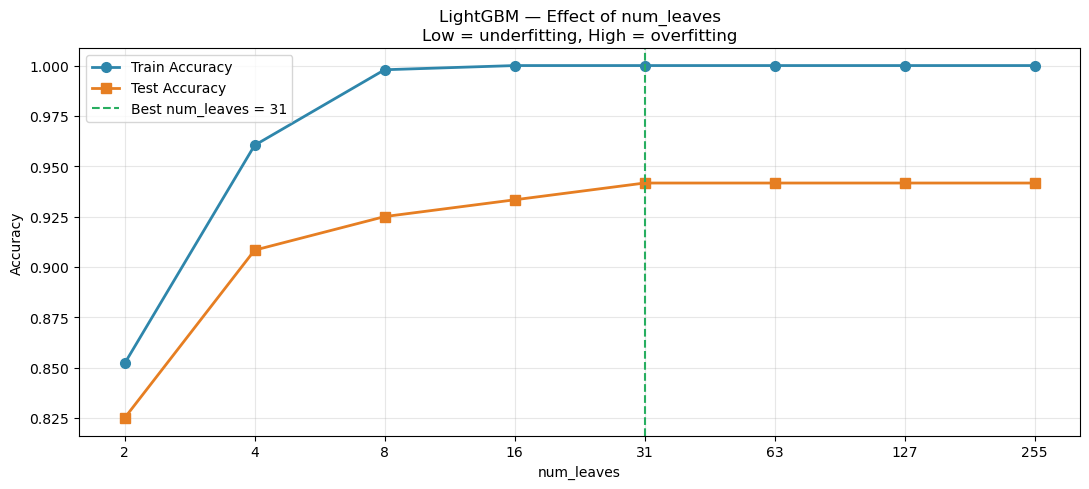

Best num_leaves : 31
Rule of thumb   : num_leaves < 2^max_depth to avoid overfitting.
For max_depth=6 -> num_leaves should be < 64.


In [18]:
np.random.seed(42)
X_nl, y_nl = make_classification(
    n_samples=600, n_features=10, n_informative=6,
    n_redundant=2, random_state=42
)
X_nl_tr, X_nl_te, y_nl_tr, y_nl_te = train_test_split(
    X_nl, y_nl, test_size=0.2, random_state=42, stratify=y_nl
)

leaves_range = [2, 4, 8, 16, 31, 63, 127, 255]
tr_accs, te_accs = [], []

for nl in leaves_range:
    clf = LGBMClassifier(
        n_estimators=100, learning_rate=0.1,
        num_leaves=nl, random_state=42,
        n_jobs=-1, verbose=-1
    )
    clf.fit(X_nl_tr, y_nl_tr)
    tr_accs.append(accuracy_score(y_nl_tr, clf.predict(X_nl_tr)))
    te_accs.append(accuracy_score(y_nl_te, clf.predict(X_nl_te)))

best_nl = leaves_range[np.argmax(te_accs)]

plt.figure(figsize=(11, 5))
plt.plot(range(len(leaves_range)), tr_accs, 'o-',
         color=COLORS['primary'], linewidth=2, markersize=7, label='Train Accuracy')
plt.plot(range(len(leaves_range)), te_accs, 's-',
         color=COLORS['secondary'], linewidth=2, markersize=7, label='Test Accuracy')
best_idx = leaves_range.index(best_nl)
plt.axvline(best_idx, color=COLORS['success'], linestyle='--',
            linewidth=1.5, label=f'Best num_leaves = {best_nl}')
plt.xticks(range(len(leaves_range)), leaves_range)
plt.xlabel('num_leaves')
plt.ylabel('Accuracy')
plt.title('LightGBM — Effect of num_leaves\nLow = underfitting, High = overfitting')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best num_leaves : {best_nl}')
print('Rule of thumb   : num_leaves < 2^max_depth to avoid overfitting.')
print('For max_depth=6 -> num_leaves should be < 64.')

## 7. Feature Importance — Split vs Gain

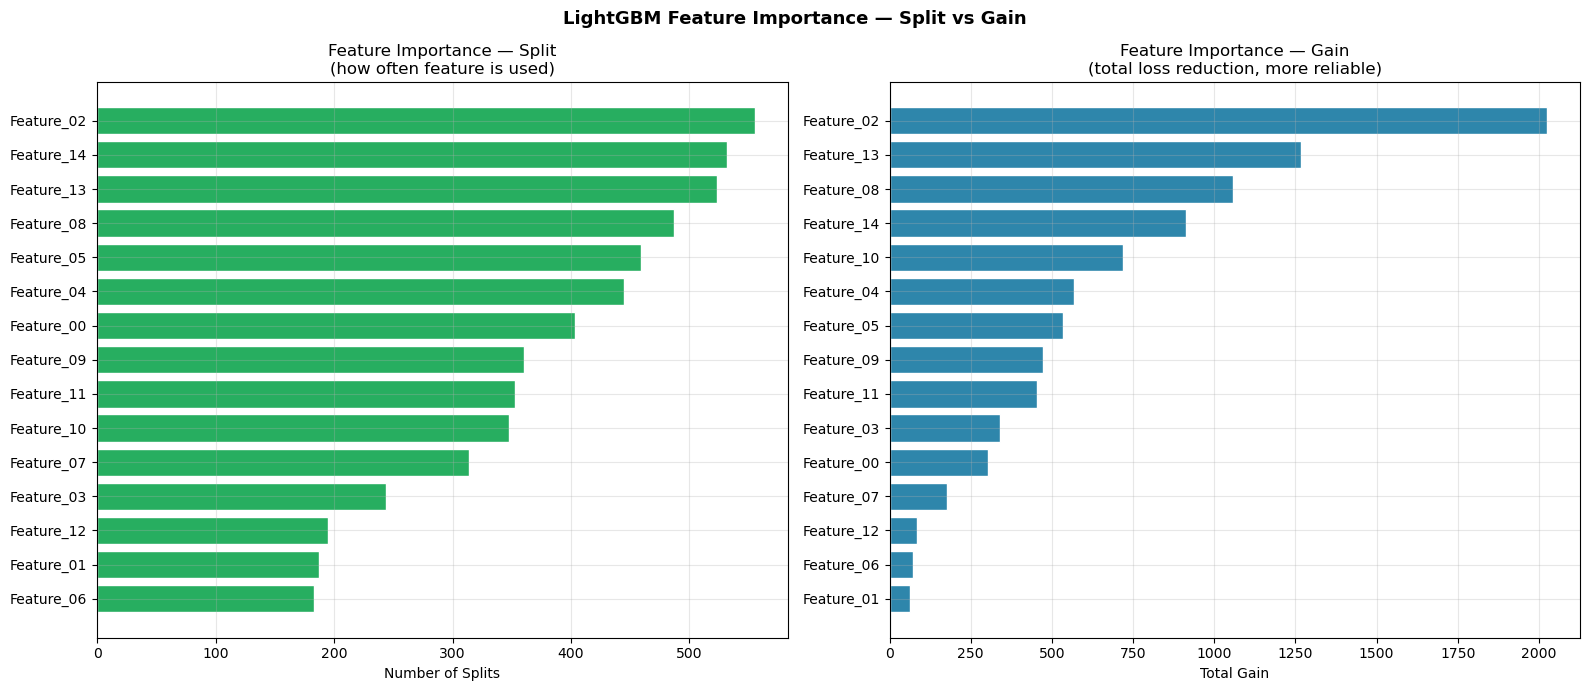

Test Accuracy : 0.9062
Test ROC-AUC  : 0.9775

Split importance can be biased toward high-cardinality features.
Gain importance is generally more reliable for interpretation.


In [19]:
np.random.seed(7)
X_imp, y_imp = make_classification(
    n_samples=800, n_features=15, n_informative=8,
    n_redundant=4, random_state=7
)
feat_names = [f'Feature_{i:02d}' for i in range(15)]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

lgbm_imp = LGBMClassifier(
    n_estimators=200, learning_rate=0.05, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_imp.fit(X_imp_tr, y_imp_tr,
             feature_name=feat_names)

imp_split = lgbm_imp.booster_.feature_importance(importance_type='split')
imp_gain  = lgbm_imp.booster_.feature_importance(importance_type='gain')

imp_df = pd.DataFrame({
    'Feature': feat_names,
    'Split':   imp_split,
    'Gain':    imp_gain
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

imp_split_s = imp_df.sort_values('Split', ascending=True)
axes[0].barh(imp_split_s['Feature'], imp_split_s['Split'],
             color=COLORS['lgbm'], edgecolor='white')
axes[0].set_xlabel('Number of Splits')
axes[0].set_title('Feature Importance — Split\n(how often feature is used)')

imp_gain_s = imp_df.sort_values('Gain', ascending=True)
axes[1].barh(imp_gain_s['Feature'], imp_gain_s['Gain'],
             color=COLORS['primary'], edgecolor='white')
axes[1].set_xlabel('Total Gain')
axes[1].set_title('Feature Importance — Gain\n(total loss reduction, more reliable)')

plt.suptitle('LightGBM Feature Importance — Split vs Gain', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Test Accuracy : {accuracy_score(y_imp_te, lgbm_imp.predict(X_imp_te)):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_imp_te, lgbm_imp.predict_proba(X_imp_te)[:,1]):.4f}')
print()
print('Split importance can be biased toward high-cardinality features.')
print('Gain importance is generally more reliable for interpretation.')

## 8. Native Categorical Feature Handling

In [20]:
np.random.seed(33)
n_cat = 800

# Numeric features
Age    = np.random.randint(20, 65, n_cat).astype(float)
Income = np.random.uniform(20000, 120000, n_cat)
Score  = np.random.uniform(300, 850, n_cat)

# Categorical features (encoded as integers for LightGBM)
Region     = np.random.randint(0, 4, n_cat)    # 0=North 1=South 2=East 3=West
Education  = np.random.randint(0, 4, n_cat)    # 0=HS 1=BSc 2=MSc 3=PhD
JobType    = np.random.randint(0, 5, n_cat)    # 0-4 job categories

X_cat = np.column_stack([Age, Income, Score, Region, Education, JobType])
feat_cat_names = ['Age','Income','Score','Region','Education','JobType']
cat_features   = ['Region','Education','JobType']   # tell LightGBM which are categorical

log_odds = (-2 + 0.02*Age + 0.000015*Income + 0.005*Score
            + 0.3*(Education==3).astype(float) - 0.2*(Region==1).astype(float))
prob     = 1 / (1 + np.exp(-log_odds))
y_cat    = (prob > np.random.uniform(0, 1, n_cat)).astype(int)

# Ensure both classes present
print(f'Class balance : {np.bincount(y_cat)}')

X_cat_tr, X_cat_te, y_cat_tr, y_cat_te = train_test_split(
    X_cat, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

# Without categorical hint — LightGBM treats all as numeric
lgbm_no_cat = LGBMClassifier(
    n_estimators=100, learning_rate=0.1, num_leaves=31,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_no_cat.fit(X_cat_tr, y_cat_tr)

# With categorical hint — LightGBM uses optimal grouping splits
lgbm_cat = LGBMClassifier(
    n_estimators=100, learning_rate=0.1, num_leaves=31,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_cat.fit(X_cat_tr, y_cat_tr,
             feature_name=feat_cat_names,
             categorical_feature=cat_features)

acc_no_cat = accuracy_score(y_cat_te, lgbm_no_cat.predict(X_cat_te))
acc_cat    = accuracy_score(y_cat_te, lgbm_cat.predict(X_cat_te))
auc_no_cat = roc_auc_score(y_cat_te, lgbm_no_cat.predict_proba(X_cat_te)[:,1])
auc_cat    = roc_auc_score(y_cat_te, lgbm_cat.predict_proba(X_cat_te)[:,1])

print(f'\nWithout categorical hint  ->  Accuracy={acc_no_cat:.4f}  AUC={auc_no_cat:.4f}')
print(f'With categorical hint     ->  Accuracy={acc_cat:.4f}  AUC={auc_cat:.4f}')
print()
print('LightGBM uses "many-vs-many" optimal partition splits for categorical features,')
print('which is more powerful than simple one-hot encoding or label encoding.')

Class balance : [ 73 727]

Without categorical hint  ->  Accuracy=0.8812  AUC=0.6322
With categorical hint     ->  Accuracy=0.8812  AUC=0.6166

LightGBM uses "many-vs-many" optimal partition splits for categorical features,
which is more powerful than simple one-hot encoding or label encoding.


## 9. LightGBM Regressor

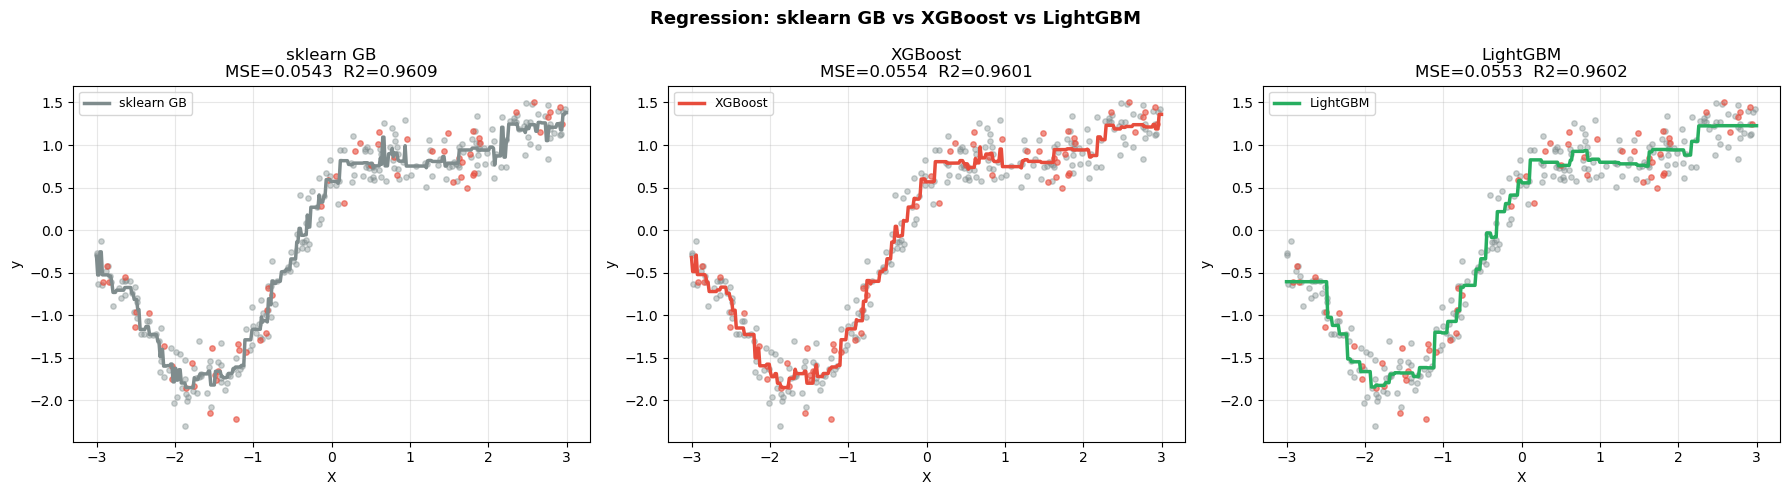

In [21]:
np.random.seed(5)
X_r = np.sort(np.random.uniform(-3, 3, 300)).reshape(-1, 1)
y_r = (np.sin(X_r).ravel() + 0.5*np.cos(2*X_r).ravel()
       + 0.2*X_r.ravel() + np.random.randn(300)*0.2)

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

from sklearn.ensemble import GradientBoostingRegressor

reg_models = {
    'sklearn GB':  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                              max_depth=3, random_state=42),
    'XGBoost':     XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3,
                                 eval_metric='rmse', random_state=42, n_jobs=-1),
    'LightGBM':    LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=31,
                                  random_state=42, n_jobs=-1, verbose=-1),
}
plot_colors = [COLORS['neutral'], COLORS['xgb'], COLORS['lgbm']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model), color in zip(axes, reg_models.items(), plot_colors):
    model.fit(X_r_tr, y_r_tr)
    mse = mean_squared_error(y_r_te, model.predict(X_r_te))
    r2  = r2_score(y_r_te, model.predict(X_r_te))
    ax.scatter(X_r_tr, y_r_tr, s=15, alpha=0.4, color=COLORS['neutral'])
    ax.scatter(X_r_te, y_r_te, s=15, alpha=0.6, color=COLORS['danger'])
    ax.plot(X_plot, model.predict(X_plot), color=color, linewidth=2.5, label=name)
    ax.set_title(f'{name}\nMSE={mse:.4f}  R2={r2:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=9)

plt.suptitle('Regression: sklearn GB vs XGBoost vs LightGBM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning with GridSearchCV

In [ ]:
param_grid = {
    'n_estimators':      [100, 200],
    'learning_rate':     [0.05, 0.1, 0.2],
    'num_leaves':        [15, 31, 63],
    'subsample':         [0.7, 1.0],
    'colsample_bytree':  [0.7, 1.0],
}

lgbm_base = LGBMClassifier(
    random_state=42, n_jobs=-1, verbose=-1
)

grid = GridSearchCV(
    lgbm_base, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_imp_tr, y_imp_tr)

best_lgbm = grid.best_estimator_
best_pred = best_lgbm.predict(X_imp_te)
best_prob = best_lgbm.predict_proba(X_imp_te)[:, 1]

print(f'Best Parameters : {grid.best_params_}')
print(f'Best CV AUC     : {grid.best_score_:.4f}')
print(f'Test Accuracy   : {accuracy_score(y_imp_te, best_pred):.4f}')
print(f'Test ROC-AUC    : {roc_auc_score(y_imp_te, best_prob):.4f}')
print(f'Test F1 Score   : {f1_score(y_imp_te, best_pred):.4f}')

cv_df = pd.DataFrame(grid.cv_results_)
cv_df = cv_df.sort_values('mean_test_score', ascending=False).head(12)

plt.figure(figsize=(12, 5))
plt.barh(range(len(cv_df)), cv_df['mean_test_score'],
         xerr=cv_df['std_test_score'],
         color=COLORS['lgbm'], edgecolor='white', alpha=0.85)
plt.yticks(range(len(cv_df)),
           [str(p) for p in cv_df['params']], fontsize=7)
plt.xlabel('Mean CV ROC-AUC')
plt.title('Top 12 GridSearchCV Configurations — LightGBM')
plt.tight_layout()
plt.show()

## 11. Real-World Offline-Safe Dataset — Bank Churn Prediction

In [ ]:
np.random.seed(42)
X_churn, y_churn = make_classification(
    n_samples=1000, n_features=12, n_informative=8,
    n_redundant=3, class_sep=0.9, random_state=42
)

feat_names_churn = ['CreditScore','Age','Tenure','Balance','NumProducts',
                    'HasCrCard','IsActiveMember','EstSalary',
                    'NumComplaints','SatisfactionScore',
                    'ProductsUsed','DigitalEngagement']

print(f'Dataset shape : {X_churn.shape}')
print(f'Class balance : {np.bincount(y_churn)}  (0=Stayed, 1=Churned)')

X_ch_tr, X_ch_te, y_ch_tr, y_ch_te = train_test_split(
    X_churn, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

lgbm_churn = LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    num_leaves=31, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1,
    reg_lambda=1.0, min_child_samples=20,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_churn.fit(X_ch_tr, y_ch_tr,
               feature_name=feat_names_churn)

ch_pred = lgbm_churn.predict(X_ch_te)
ch_prob = lgbm_churn.predict_proba(X_ch_te)[:, 1]

print(f'\nTest Accuracy : {accuracy_score(y_ch_te, ch_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_ch_te, ch_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_ch_te, ch_pred):.4f}')

cv_scores = cross_val_score(
    lgbm_churn, X_churn, y_churn,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

## 12. Full Model Evaluation

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_ch = confusion_matrix(y_ch_te, ch_pred)
ConfusionMatrixDisplay(cm_ch, display_labels=['Stayed','Churned']).plot(
    ax=axes[0], colorbar=False, cmap='Greens'
)
axes[0].set_title('Confusion Matrix — Bank Churn')

fpr_c, tpr_c, _ = roc_curve(y_ch_te, ch_prob)
auc_c = roc_auc_score(y_ch_te, ch_prob)
axes[1].plot(fpr_c, tpr_c, color=COLORS['lgbm'], linewidth=2.5,
             label=f'LightGBM (AUC={auc_c:.4f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1.5, label='Random')
axes[1].fill_between(fpr_c, tpr_c, alpha=0.15, color=COLORS['lgbm'])
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve')
axes[1].legend()

gain_imp = lgbm_churn.booster_.feature_importance(importance_type='gain')
imp_ch   = pd.Series(gain_imp, index=feat_names_churn).sort_values(ascending=True)
axes[2].barh(imp_ch.index, imp_ch.values,
             color=COLORS['lgbm'], edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Gain Importance')
axes[2].set_title('Feature Importance (Gain)')

plt.suptitle('LightGBM — Bank Churn Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Classification Report:')
print(classification_report(y_ch_te, ch_pred, target_names=['Stayed','Churned']))

## 13. XGBoost vs LightGBM — Speed & Accuracy Comparison

In [ ]:
n_trials = 12
results  = {'XGBoost': [], 'LightGBM': []}
times    = {'XGBoost': [], 'LightGBM': []}

for seed in range(n_trials):
    X_t, y_t = make_classification(
        n_samples=800, n_features=20, n_informative=12,
        n_redundant=5, random_state=seed
    )
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_t, y_t, test_size=0.2, random_state=seed, stratify=y_t
    )
    models_cmp = {
        'XGBoost':  XGBClassifier(n_estimators=200, learning_rate=0.05,
                                   max_depth=4, subsample=0.8,
                                   colsample_bytree=0.8,
                                   eval_metric='logloss',
                                   random_state=seed, n_jobs=-1),
        'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                    num_leaves=31, subsample=0.8,
                                    colsample_bytree=0.8,
                                    random_state=seed, n_jobs=-1, verbose=-1),
    }
    for name, model in models_cmp.items():
        t0 = time.time()
        model.fit(X_tr, y_tr)
        t1 = time.time()
        results[name].append(roc_auc_score(y_te, model.predict_proba(X_te)[:,1]))
        times[name].append(t1 - t0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
names  = ['XGBoost', 'LightGBM']
colors = [COLORS['xgb'], COLORS['lgbm']]

# AUC line plot
for name, color in zip(names, colors):
    axes[0].plot(results[name], 'o-', color=color, linewidth=2, markersize=6, label=name)
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Test ROC-AUC')
axes[0].set_title('ROC-AUC per Trial')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot([results[n] for n in names], labels=names,
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[1].set_ylabel('Test ROC-AUC')
axes[1].set_title('ROC-AUC Distribution')

# Speed comparison
mean_times = [np.mean(times[n])*1000 for n in names]
bars = axes[2].bar(names, mean_times, color=colors, edgecolor='white', width=0.4)
axes[2].set_ylabel('Avg Training Time (ms)')
axes[2].set_title('Training Speed Comparison')
for bar, t in zip(bars, mean_times):
    axes[2].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+2, f'{t:.0f}ms',
                 ha='center', fontweight='bold')

plt.suptitle('XGBoost vs LightGBM — 12 Trial Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'{'Model':<12} {'Mean AUC':>10} {'Std':>8} {'Avg Time (ms)':>15}')
print('-' * 48)
for name in names:
    m = np.mean(results[name])
    s = np.std(results[name])
    t = np.mean(times[name]) * 1000
    print(f'{name:<12} {m:>10.4f} {s:>8.4f} {t:>15.1f}')

speedup = np.mean(times['XGBoost']) / np.mean(times['LightGBM'])
print(f'\nLightGBM is {speedup:.1f}x faster than XGBoost on this benchmark.')

## 14. Final Summary & Key Takeaways

In [ ]:
print('=' * 70)
print('               LIGHTGBM - KEY TAKEAWAYS')
print('=' * 70)

takeaways = [
    ('Core idea',          'Leaf-wise gradient boosting with histogram-based splits'),
    ('vs XGBoost',         'Faster training, lower memory, native categoricals'),
    ('num_leaves',         'KEY param: controls tree complexity (not max_depth alone)'),
    ('GOSS',               'Keeps hard examples, drops easy ones -> faster training'),
    ('EFB',                'Bundles mutually exclusive features -> fewer effective features'),
    ('Categorical',        'Pass categorical_feature list -> no one-hot encoding needed'),
    ('Early stopping',     'Use lgb.early_stopping callback with eval_set'),
    ('learning_rate',      'Lower is better; pair with more n_estimators + early stopping'),
    ('min_child_samples',  'Increase on small datasets to prevent overfitting'),
    ('Feature importance', 'Split (fast) vs Gain (reliable) — prefer Gain'),
    ('Feature scaling',    'NOT required — tree-based splits'),
    ('Weakness',           'Leaf-wise can overfit on small data; more hyperparameters'),
    ('Small data rule',    'Use max_depth to limit growth when n_samples < 10000'),
    ('Next step',          'CatBoost: best native categorical handling of all three'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<22}  ->  {detail}')

print('=' * 70)

---
## Practice Exercises

1. **Tune num_leaves and max_depth together** — what combination gives best results on the churn dataset?
2. **Compare DART booster** — set `boosting_type='dart'` and compare with `'gbdt'`.
3. **Use the native lgb.Dataset API** — convert data to `lgb.Dataset` and use `lgb.train()` directly.
4. **Add more categorical features** and compare accuracy with vs without `categorical_feature` hint.
5. **Benchmark on a larger dataset** — generate 100k samples and compare training time vs XGBoost.
6. **Plot SHAP values** — install `shap` and use `shap.TreeExplainer` to explain LightGBM predictions.

---
*Notebook created for the ML Repository — LightGBM module.*